# MTA Subway Station Data Pre-processing

The purpose of this process is to create one subway-proximity value for each of the 263 TLC taxi zones. The sequence below follows Section 4.3.2 of the report so that each code output can be used as supporting evidence for the corresponding subsection.


## 1 Import the Required Libraries


In [1]:
# Import the tools used to manage file paths, tables, geographic data, and displayed results.
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pyproj import CRS
from IPython.display import display


## 2 Define the Input and Output Paths


In [2]:
# Define the locations of the source data and the processed output file.
PROJECT_ROOT = Path(r"C:\Asia Pacific University\All Module Notes\Semister-5\Investigations\FYP Semester 1\Progress\fyp")
MTA_FILE = PROJECT_ROOT / "all_raw_data" / "mta_subway" / "MTA_Subway_Stations.csv"
TAXI_ZONE_FILE = PROJECT_ROOT / "processed_outputs" / "taxi_zone" / "nyc_taxi_zones_cleaned.gpkg"
OUTPUT_DIR = PROJECT_ROOT / "processed_outputs" / "mta_subway"
OUTPUT_FILE = OUTPUT_DIR / "nyc_taxi_zone_subway_proximity.csv"


## 3 Load the MTA Station Records


In [3]:
# Load the original MTA station records and display the first five rows.
stations_raw = pd.read_csv(MTA_FILE)
stations_raw.head(5)


,GTFS Stop ID,Station ID,Complex ID,Division,Line,Stop Name,Borough,CBD,Daytime Routes,Structure,GTFS Latitude,GTFS Longitude,North Direction Label,South Direction Label,ADA,ADA Northbound,ADA Southbound,ADA Notes,Georeference
0,R01,1,1,BMT,Astoria,Astoria-Ditmars Blvd,Q,False,N W,Elevated,40.775036,-73.912034,Last Stop,Manhattan,0,0,0,NaN,POINT (-73.912034 40.775036)
1,R03,2,2,BMT,Astoria,Astoria Blvd,Q,False,N W,Elevated,40.770258,-73.917843,Astoria,Manhattan,1,1,1,NaN,POINT (-73.917843 40.770258)
2,R04,3,3,BMT,Astoria,30 Av,Q,False,N W,Elevated,40.766779,-73.921479,Astoria,Manhattan,0,0,0,NaN,POINT (-73.921479 40.766779)
3,R05,4,4,BMT,Astoria,Broadway,Q,False,N W,Elevated,40.761820,-73.925508,Astoria,Manhattan,0,0,0,NaN,POINT (-73.925508 40.76182)
4,R06,5,5,BMT,Astoria,36 Av,Q,False,N W,Elevated,40.756804,-73.929575,Astoria,Manhattan,0,0,0,NaN,POINT (-73.929575 40.756804)


**Interpretation:** The first five rows confirm that the source data was loaded correctly and that the station information is readable before preprocessing.


## 4 Inspect the Dataset Dimensions and Column Names


In [4]:
# Show the number of records, number of fields, and all available column names.
print("Raw shape:", stations_raw.shape)
print("Columns:", stations_raw.columns.tolist())
print("Data types:\n", stations_raw.dtypes)


Raw shape: (496, 19)
Columns: ['GTFS Stop ID', 'Station ID', 'Complex ID', 'Division', 'Line', 'Stop Name', 'Borough', 'CBD', 'Daytime Routes', 'Structure', 'GTFS Latitude', 'GTFS Longitude', 'North Direction Label', 'South Direction Label', 'ADA', 'ADA Northbound', 'ADA Southbound', 'ADA Notes', 'Georeference']
Data types:
 GTFS Stop ID              object
Station ID                 int64
Complex ID                 int64
Division                  object
Line                      object
Stop Name                 object
Borough                   object
CBD                         bool
Daytime Routes            object
Structure                 object
GTFS Latitude            float64
GTFS Longitude           float64
North Direction Label     object
South Direction Label     object
ADA                        int64
ADA Northbound             int64
ADA Southbound             int64
ADA Notes                 object
Georeference              object
dtype: object


**Interpretation:** The raw file contains 496 station records and 19 fields, providing the starting point for the following quality checks.


## 5 Verify the Required Station Fields


In [5]:
# Confirm that the station identifiers, service details, and coordinates required for the analysis are present.
required_columns = [
    "GTFS Stop ID", "Station ID", "Complex ID", "Stop Name",
    "Borough", "Division", "Daytime Routes",
    "GTFS Latitude", "GTFS Longitude"
]

missing_columns = sorted(set(required_columns) - set(stations_raw.columns))
print("Missing required columns:", missing_columns)
display(stations_raw[required_columns].head())


Missing required columns: []


,GTFS Stop ID,Station ID,Complex ID,Stop Name,Borough,Division,Daytime Routes,GTFS Latitude,GTFS Longitude
0,R01,1,1,Astoria-Ditmars Blvd,Q,BMT,N W,40.775036,-73.912034
1,R03,2,2,Astoria Blvd,Q,BMT,N W,40.770258,-73.917843
2,R04,3,3,30 Av,Q,BMT,N W,40.766779,-73.921479
3,R05,4,4,Broadway,Q,BMT,N W,40.761820,-73.925508
4,R06,5,5,36 Av,Q,BMT,N W,40.756804,-73.929575


**Interpretation:** The empty missing-field list and the displayed sample confirm that all information required to identify and locate the stations is available.


## 6 Check Station Coordinates


In [6]:
# Check whether the station coordinates are complete and fall within a broad New York City area.
missing_latitudes = int(stations_raw["GTFS Latitude"].isna().sum())
missing_longitudes = int(stations_raw["GTFS Longitude"].isna().sum())

coordinate_valid = (
    stations_raw["GTFS Latitude"].between(40.4, 41.0)
    & stations_raw["GTFS Longitude"].between(-74.3, -73.6)
)

coordinate_summary = pd.Series({
    "missing_latitudes": missing_latitudes,
    "missing_longitudes": missing_longitudes,
    "coordinates_outside_validation_range": int((~coordinate_valid).sum()),
    "minimum_latitude": stations_raw["GTFS Latitude"].min(),
    "maximum_latitude": stations_raw["GTFS Latitude"].max(),
    "minimum_longitude": stations_raw["GTFS Longitude"].min(),
    "maximum_longitude": stations_raw["GTFS Longitude"].max(),
})
display(coordinate_summary.to_frame("value"))


,value
missing_latitudes,0.000000
missing_longitudes,0.000000
coordinates_outside_validation_range,0.000000
minimum_latitude,40.512764
maximum_latitude,40.903125
minimum_longitude,-74.251961
maximum_longitude,-73.755405


**Interpretation:** No latitude or longitude values are missing or outside the broad validation range, so all records can be used in the spatial process.


## 7 Identify Repeated Station Locations


In [7]:
# Find rows that represent the same physical station location under different route groupings.
duplicate_locations = stations_raw.duplicated(
    subset=["Station ID", "GTFS Latitude", "GTFS Longitude"],
    keep=False,
)

print("Rows belonging to repeated physical locations:", int(duplicate_locations.sum()))
display(
    stations_raw.loc[duplicate_locations, [
        "Station ID", "Stop Name", "Daytime Routes",
        "GTFS Latitude", "GTFS Longitude"
    ]].sort_values(["Station ID", "Daytime Routes"])
)


Rows belonging to repeated physical locations: 6


,Station ID,Stop Name,Daytime Routes,GTFS Latitude,GTFS Longitude
149,151,145 St,A C,40.824783,-73.944216
150,151,145 St,B D,40.824783,-73.944216
166,167,W 4 St-Wash Sq,A C E,40.732338,-74.000495
167,167,W 4 St-Wash Sq,B D F M,40.732338,-74.000495
462,461,Queensboro Plaza,7,40.750582,-73.940202
461,461,Queensboro Plaza,N W,40.750582,-73.940202


**Interpretation:** Six rows refer to three repeated physical locations. Keeping only one record per location prevents the same point from being represented more than once.


## 8 Summarise Initial Data Quality


In [8]:
# Summarise the initial checks and stop the process if required fields or coordinates are unsuitable.
quality_summary = pd.Series({
    "rows": len(stations_raw),
    "columns": stations_raw.shape[1],
    "missing_required_columns": len(missing_columns),
    "missing_latitudes": missing_latitudes,
    "missing_longitudes": missing_longitudes,
    "coordinates_outside_validation_range": int((~coordinate_valid).sum()),
    "duplicate_physical_station_rows": int(duplicate_locations.sum()),
    "unique_station_locations": int(
        stations_raw[["Station ID", "GTFS Latitude", "GTFS Longitude"]]
        .drop_duplicates()
        .shape[0]
    ),
    "staten_island_railway_records": int(stations_raw["Division"].eq("SIR").sum()),
})
display(quality_summary.to_frame("value"))

assert not missing_columns
assert stations_raw[["GTFS Latitude", "GTFS Longitude"]].notna().all().all()
assert coordinate_valid.all()


,value
rows,496
columns,19
missing_required_columns,0
missing_latitudes,0
missing_longitudes,0
coordinates_outside_validation_range,0
duplicate_physical_station_rows,6
unique_station_locations,493
staten_island_railway_records,21


**Interpretation:** The summary confirms that the file is structurally complete and geographically usable, while also recording the repeated locations that require cleaning.


## 9 Retain Relevant Station Fields


In [9]:
# Retain only the station fields needed for identification, review, and proximity calculation.
stations_selected = stations_raw[required_columns].copy()
display(stations_selected.head())


,GTFS Stop ID,Station ID,Complex ID,Stop Name,Borough,Division,Daytime Routes,GTFS Latitude,GTFS Longitude
0,R01,1,1,Astoria-Ditmars Blvd,Q,BMT,N W,40.775036,-73.912034
1,R03,2,2,Astoria Blvd,Q,BMT,N W,40.770258,-73.917843
2,R04,3,3,30 Av,Q,BMT,N W,40.766779,-73.921479
3,R05,4,4,Broadway,Q,BMT,N W,40.761820,-73.925508
4,R06,5,5,36 Av,Q,BMT,N W,40.756804,-73.929575


**Interpretation:** The reduced table keeps the fields needed for the proximity feature and removes unrelated source fields from the remaining process.


## 10 Remove Repeated Station Locations


In [10]:
# Keep one record for each physical station location.
stations_clean = (
    stations_selected
    .drop_duplicates(subset=["Station ID", "GTFS Latitude", "GTFS Longitude"])
    .sort_values("Station ID")
    .reset_index(drop=True)
)

print("Retained station locations:", len(stations_clean))


Retained station locations: 493


**Interpretation:** After removing three repeated route-specific rows, 493 distinct physical station locations remain for distance calculation.


## 11 Review the Cleaned Station Data


In [11]:
# Review the number of removed records and confirm that Staten Island Railway locations remain included.
cleaning_summary = pd.Series({
    "raw_records": len(stations_raw),
    "duplicate_route_rows_removed": len(stations_raw) - len(stations_clean),
    "retained_station_locations": len(stations_clean),
    "retained_SIR_locations": int(stations_clean["Division"].eq("SIR").sum()),
})
display(cleaning_summary.to_frame("value"))

assert len(stations_clean) == 493
assert not stations_clean.duplicated(
    ["Station ID", "GTFS Latitude", "GTFS Longitude"]
).any()


,value
raw_records,496
duplicate_route_rows_removed,3
retained_station_locations,493
retained_SIR_locations,21


**Interpretation:** The cleaned data contains 493 distinct station locations, and all 21 Staten Island Railway locations are retained for geographic coverage.


## 12 Create Station Map Points


In [12]:
# Convert each longitude and latitude pair into a station point on the map.
stations_gdf = gpd.GeoDataFrame(
    stations_clean.rename(columns={"Borough": "station_borough"}),
    geometry=gpd.points_from_xy(
        stations_clean["GTFS Longitude"],
        stations_clean["GTFS Latitude"],
    ),
    crs="EPSG:4326",
)

print("Initial station CRS:", stations_gdf.crs)
print("Geometry types:", stations_gdf.geometry.geom_type.unique().tolist())


Initial station CRS: EPSG:4326
Geometry types: ['Point']


**Interpretation:** Each cleaned station location is now represented as a map point using its original longitude and latitude coordinates.


## 13 Align the Station and Taxi-Zone Coordinate Systems


In [13]:
# Convert the station points to the same projected coordinate system used by the taxi zones.
stations_gdf = stations_gdf.to_crs("EPSG:2263")

projection_summary = pd.Series({
    "station_locations": len(stations_gdf),
    "projected_CRS": str(stations_gdf.crs),
    "missing_geometry": int(stations_gdf.geometry.isna().sum()),
})
display(projection_summary.to_frame("value"))


,value
station_locations,493
projected_CRS,EPSG:2263
missing_geometry,0


**Interpretation:** All 493 station points are represented in the same projected coordinate system as the taxi zones, allowing consistent distance measurement.


## 14 Load the Cleaned Taxi-Zone Boundaries


In [14]:
# Load the cleaned TLC taxi-zone boundaries used to create the zone-level proximity feature.
taxi_zones = gpd.read_file(TAXI_ZONE_FILE, layer="nyc_taxi_zones")

print("Taxi-zone shape:", taxi_zones.shape)
print("Taxi-zone CRS:", taxi_zones.crs)


Taxi-zone shape: (262, 5)
Taxi-zone CRS: EPSG:2263


**Interpretation:** The cleaned taxi-zone boundaries are available as the 263 geographic areas for which proximity values will be calculated.


## 15 Check the Taxi-Zone Data


In [28]:
# Confirm that the taxi-zone data contains 262 unique zones in the required coordinate system.
zone_input_checks = pd.Series({
    "rows_equal_262": len(taxi_zones) == 262,
    "LocationID_unique": taxi_zones["LocationID"].is_unique,
    "CRS_is_EPSG_2263": taxi_zones.crs.to_epsg() == 2263,
})
display(zone_input_checks.to_frame("passed"))
assert zone_input_checks.all()


,passed
rows_equal_262,True
LocationID_unique,True
CRS_is_EPSG_2263,True


**Interpretation:** All checks pass, confirming that the 263 TLC taxi zones are unique and spatially compatible with the station points.


## 16 Standardise and Validate Taxi-Zone Borough Names


Borough values before cleaning: ['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']


,passed
all_names_recognised,True
five_NYC_boroughs_present,True
EWR_excluded_from_NYC_view,True
full_262_zone_data_preserved,True


,LocationID,borough,zone


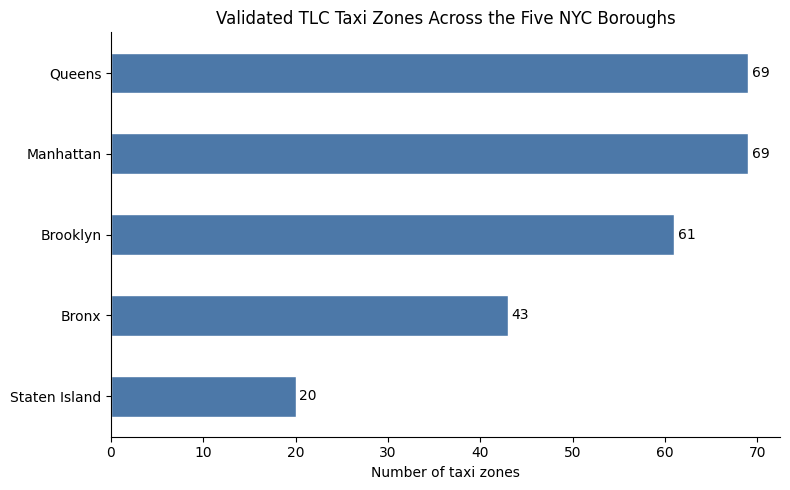

In [16]:
# Check the borough values, correct their names, and create an NYC-only view for borough analysis.
raw_borough_values = sorted(taxi_zones["borough"].dropna().astype(str).unique())
print("Borough values before cleaning:", raw_borough_values)

borough_name_corrections = {
    "MANHATTAN": "Manhattan",
    "BROOKLYN": "Brooklyn",
    "QUEENS": "Queens",
    "BRONX": "Bronx",
    "STATEN ISLAND": "Staten Island",
    "EWR": "EWR",
    "EWD": "EWR",
}

taxi_zones["borough"] = (
    taxi_zones["borough"]
    .astype("string")
    .str.strip()
    .str.upper()
    .map(borough_name_corrections)
)

nyc_boroughs = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]
unexpected_boroughs = sorted(
    set(taxi_zones["borough"].dropna()) - set(nyc_boroughs) - {"EWR"}
)
missing_borough_rows = int(taxi_zones["borough"].isna().sum())
outside_nyc_zones = taxi_zones.loc[
    ~taxi_zones["borough"].isin(nyc_boroughs),
    ["LocationID", "borough", "zone"],
].copy()
taxi_zones_nyc = taxi_zones[taxi_zones["borough"].isin(nyc_boroughs)].copy()

borough_check = pd.Series({
    "all_names_recognised": not unexpected_boroughs and missing_borough_rows == 0,
    "five_NYC_boroughs_present": set(taxi_zones_nyc["borough"].unique()) == set(nyc_boroughs),
    "EWR_excluded_from_NYC_view": "EWR" not in set(taxi_zones_nyc["borough"]),
    "full_262_zone_data_preserved": len(taxi_zones) == 262,
})

display(borough_check.to_frame("passed"))
display(outside_nyc_zones)
assert borough_check.all(), "The taxi-zone borough check failed."

# Plot the number of taxi zones retained in each validated NYC borough.
borough_zone_counts = taxi_zones_nyc["borough"].value_counts().reindex(nyc_boroughs)
ax = borough_zone_counts.sort_values().plot(
    kind="barh", figsize=(8, 5), color="#4C78A8", edgecolor="white"
)
for bar, count in zip(ax.patches, borough_zone_counts.sort_values().values):
    ax.text(count + 0.4, bar.get_y() + bar.get_height() / 2, str(count), va="center")
ax.set_title("Validated TLC Taxi Zones Across the Five NYC Boroughs")
ax.set_xlabel("Number of taxi zones")
ax.set_ylabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


**Interpretation:** The check standardises the five New York City borough names and confirms that they are suitable for borough-level analysis. The Newark Airport zone is identified as EWR and excluded only from the NYC-focused maps and borough summaries. The original 263-zone dataset remains unchanged for the proximity calculation and final integration.


## 17 Validate MTA Station Coverage Across NYC Boroughs


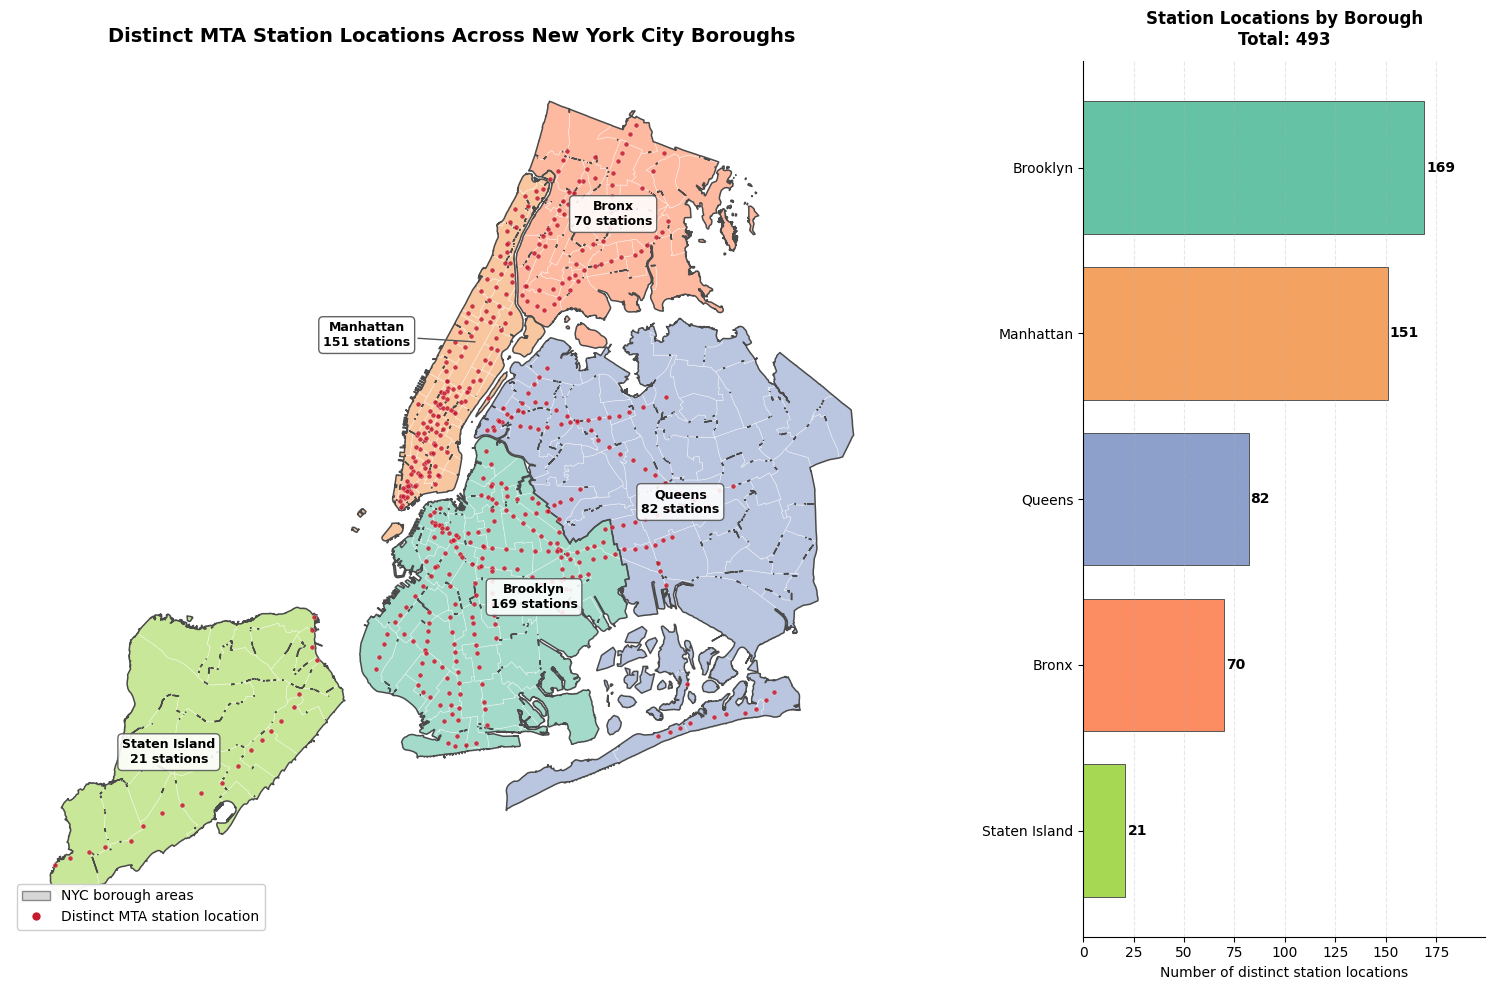

In [17]:
# Show station coverage across the five validated NYC boroughs and compare their station totals.
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

station_borough_names = {
    "M": "Manhattan",
    "Bk": "Brooklyn",
    "Q": "Queens",
    "Bx": "Bronx",
    "SI": "Staten Island",
}
borough_colours = {
    "Manhattan": "#F4A261",
    "Brooklyn": "#66C2A5",
    "Queens": "#8DA0CB",
    "Bronx": "#FC8D62",
    "Staten Island": "#A6D854",
}

stations_map = stations_gdf.copy()
stations_map["borough_name"] = stations_map["station_borough"].map(station_borough_names)
station_counts = (
    stations_map["borough_name"]
    .value_counts()
    .reindex(nyc_boroughs, fill_value=0)
    .astype(int)
)

assert stations_map["borough_name"].notna().all(), "An unexpected station borough code was found."
assert station_counts.sum() == len(stations_map) == 493

borough_boundaries = taxi_zones_nyc.dissolve(by="borough", as_index=False)
fig, (ax_map, ax_bar) = plt.subplots(
    1, 2, figsize=(16, 10), gridspec_kw={"width_ratios": [3.2, 1.2]}
)

for borough_name, colour in borough_colours.items():
    taxi_zones_nyc[taxi_zones_nyc["borough"] == borough_name].plot(
        ax=ax_map, facecolor=colour, edgecolor="white", linewidth=0.45, alpha=0.60
    )

borough_boundaries.boundary.plot(ax=ax_map, color="#4A4A4A", linewidth=1.1)
stations_map.plot(
    ax=ax_map, color="#C51B2D", edgecolor="white", linewidth=0.25,
    markersize=13, alpha=0.85, zorder=3
)

for _, borough_row in borough_boundaries.iterrows():
    borough_name = borough_row["borough"]
    label_point = borough_row.geometry.representative_point()
    label_text = f"{borough_name}\n{station_counts[borough_name]} stations"

    if borough_name == "Manhattan":
        ax_map.annotate(
            label_text, xy=(label_point.x, label_point.y), xytext=(-80, 5),
            textcoords="offset points", ha="center", va="center", fontsize=9,
            fontweight="bold",
            bbox={"boxstyle": "round,pad=0.35", "facecolor": "white",
                  "edgecolor": "#555555", "alpha": 0.92},
            arrowprops={"arrowstyle": "-", "color": "#555555", "linewidth": 1},
            zorder=4,
        )
    else:
        ax_map.text(
            label_point.x, label_point.y, label_text, ha="center", va="center",
            fontsize=9, fontweight="bold",
            bbox={"boxstyle": "round,pad=0.35", "facecolor": "white",
                  "edgecolor": "#555555", "alpha": 0.88},
            zorder=4,
        )

map_legend = [
    Patch(facecolor="#BDBDBD", edgecolor="#4A4A4A", alpha=0.60, label="NYC borough areas"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#C51B2D",
           markeredgecolor="white", markersize=7, label="Distinct MTA station location"),
]
ax_map.legend(handles=map_legend, loc="lower left", frameon=True, framealpha=0.95)
ax_map.set_title(
    "Distinct MTA Station Locations Across New York City Boroughs",
    fontsize=14, fontweight="bold", pad=14
)
ax_map.set_axis_off()

chart_counts = station_counts.sort_values()
bars = ax_bar.barh(
    chart_counts.index, chart_counts.values,
    color=[borough_colours[name] for name in chart_counts.index],
    edgecolor="#555555", linewidth=0.7
)
for bar, count in zip(bars, chart_counts.values):
    ax_bar.text(
        bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
        str(count), va="center", fontsize=10, fontweight="bold"
    )
ax_bar.set_xlim(0, chart_counts.max() * 1.18)
ax_bar.set_title(
    f"Station Locations by Borough\nTotal: {station_counts.sum():,}",
    fontsize=12, fontweight="bold", pad=12
)
ax_bar.set_xlabel("Number of distinct station locations")
ax_bar.set_ylabel("")
ax_bar.grid(axis="x", linestyle="--", alpha=0.30)
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


**Interpretation:** The map confirms that all 493 cleaned MTA station locations align with the five validated New York City boroughs. The labels and supporting chart show the exact number of distinct station locations in each borough. EWR is not displayed because it is outside the NYC study area.


## 18 Create One Centre Point for Each Taxi Zone


In [18]:
# Create one centre point for each taxi zone as the reference location for measuring proximity.
zone_centroids = taxi_zones.copy()
zone_centroids["geometry"] = zone_centroids.geometry.centroid

print("Centroids created:", len(zone_centroids))
print("Centroid geometry types:", zone_centroids.geometry.geom_type.unique().tolist())


Centroids created: 262
Centroid geometry types: ['Point']


**Interpretation:** One centre point is created for each of the 263 taxi zones, providing a consistent starting location for the distance calculation.


## 19 Identify the Nearest MTA Station


In [19]:
# Match each taxi-zone centre point with its nearest retained MTA station location.
station_join_fields = [
    "Station ID", "Stop Name", "station_borough",
    "Division", "GTFS Latitude", "GTFS Longitude", "geometry"
]

nearest = gpd.sjoin_nearest(
    zone_centroids,
    stations_gdf[station_join_fields],
    how="left",
    distance_col="distance_us_survey_feet",
)

print("Nearest-station matches:", len(nearest))


Nearest-station matches: 262


**Interpretation:** The nearest-station matching produces one MTA station result for each taxi-zone centre point.


## 20 Prepare the Zone-to-Station Results


In [20]:
# Keep clear zone and nearest-station details so each match can be reviewed.
zone_proximity = nearest[[
    "LocationID", "borough", "zone",
    "Station ID", "Stop Name", "station_borough", "Division",
    "GTFS Latitude", "GTFS Longitude", "distance_us_survey_feet"
]].rename(columns={
    "Station ID": "nearest_station_id",
    "Stop Name": "nearest_station_name",
    "Division": "nearest_station_division",
    "GTFS Latitude": "nearest_station_latitude",
    "GTFS Longitude": "nearest_station_longitude",
})

display(zone_proximity.head())


,LocationID,borough,zone,nearest_station_id,nearest_station_name,station_borough,nearest_station_division,nearest_station_latitude,nearest_station_longitude,distance_us_survey_feet
0,2,Queens,Jamaica Bay,199,Broad Channel,Q,IND,40.608382,-73.815925,5244.810715
1,3,Bronx,Allerton/Pelham Gardens,444,Gun Hill Rd,Bx,IRT,40.869526,-73.846384,1862.985048
2,4,Manhattan,Alphabet City,119,1 Av,M,BMT,40.730953,-73.981628,2924.187531
3,5,Staten Island,Arden Heights,515,Annadale,SI,SIR,40.540460,-74.178217,5281.540726
4,6,Staten Island,Arrochar/Fort Wadsworth,505,Grasmere,SI,SIR,40.603117,-74.084087,3568.350993


**Interpretation:** The resulting table links each taxi zone to the identity and location of its nearest MTA station before the distance is converted to kilometres.


## 21 Create the Subway-Proximity Feature


In [21]:
# Convert the measured CRS distance to kilometres.
crs_unit_to_metre = CRS.from_user_input(
    zone_centroids.crs
).axis_info[0].unit_conversion_factor

zone_proximity["subway_proximity_km"] = (
    zone_proximity["distance_us_survey_feet"]
    * crs_unit_to_metre
    / 1000
)

zone_proximity = (
    zone_proximity
    .drop(columns="distance_us_survey_feet")
    .sort_values("LocationID")
    .reset_index(drop=True)
)

display(zone_proximity.head())

,LocationID,borough,zone,nearest_station_id,nearest_station_name,station_borough,nearest_station_division,nearest_station_latitude,nearest_station_longitude,subway_proximity_km
0,2,Queens,Jamaica Bay,199,Broad Channel,Q,IND,40.608382,-73.815925,1.598622
1,3,Bronx,Allerton/Pelham Gardens,444,Gun Hill Rd,Bx,IRT,40.869526,-73.846384,0.567839
2,4,Manhattan,Alphabet City,119,1 Av,M,BMT,40.730953,-73.981628,0.891294
3,5,Staten Island,Arden Heights,515,Annadale,SI,SIR,40.540460,-74.178217,1.609817
4,6,Staten Island,Arrochar/Fort Wadsworth,505,Grasmere,SI,SIR,40.603117,-74.084087,1.087636


**Interpretation:** The subway_proximity_km field represents the straight-line distance from each taxi-zone centre to its nearest retained MTA station location.


## 22 Map Subway Proximity Across NYC Taxi Zones


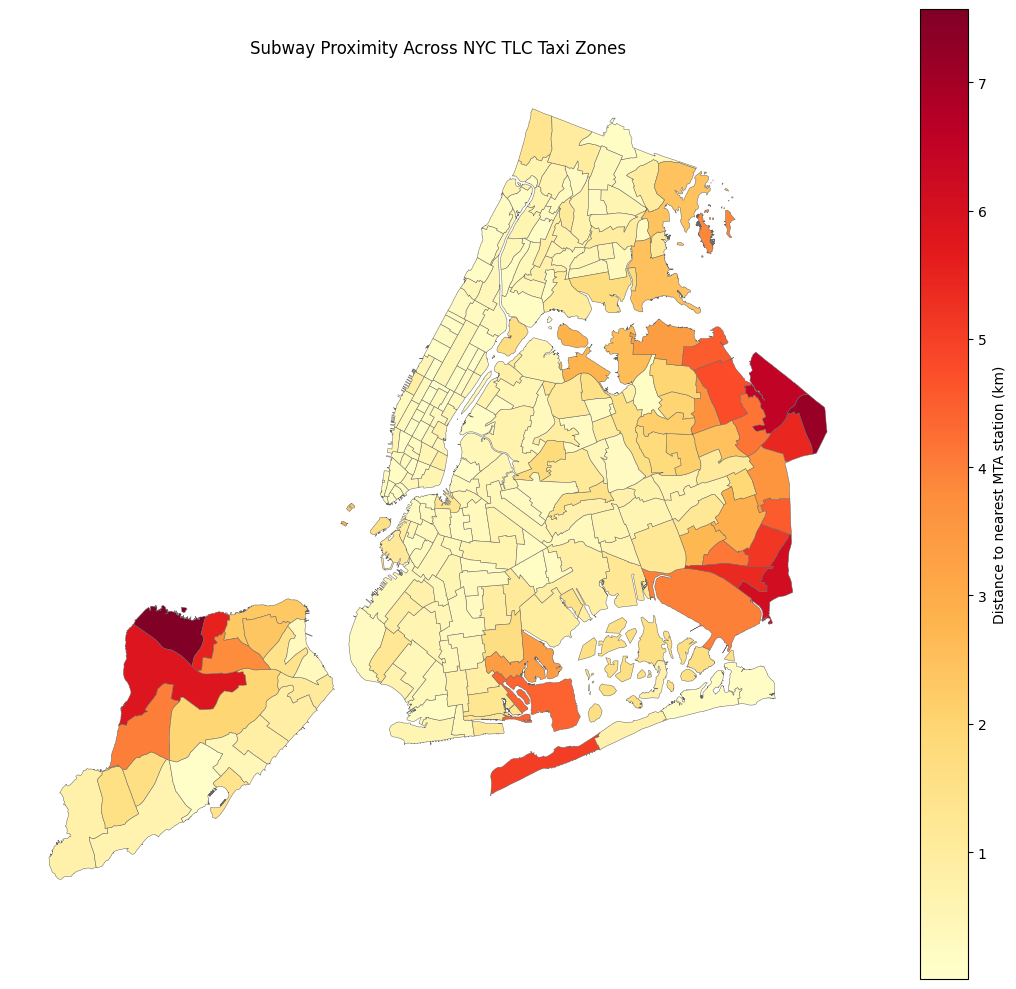

In [22]:
# Map the calculated subway-proximity values across the validated NYC taxi zones.
proximity_map = taxi_zones_nyc.merge(
    zone_proximity[["LocationID", "subway_proximity_km"]],
    on="LocationID",
    how="left",
    validate="one_to_one",
)
assert proximity_map["subway_proximity_km"].notna().all()

fig, ax = plt.subplots(figsize=(11, 10))
proximity_map.plot(
    column="subway_proximity_km",
    cmap="YlOrRd",
    linewidth=0.35,
    edgecolor="#666666",
    legend=True,
    legend_kwds={"label": "Distance to nearest MTA station (km)"},
    ax=ax,
)
ax.set_title("Subway Proximity Across NYC TLC Taxi Zones", pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()


**Interpretation:** Lighter taxi zones are closer to an MTA station, while darker zones are farther away. The map validates the geographic pattern of the calculated feature and helps reveal unusually distant areas. EWR is excluded because this is an NYC-focused validation map.


## 23 Review Proximity by Borough


In [23]:
# Summarise proximity across the five validated NYC boroughs.
borough_summary = (
    zone_proximity[zone_proximity["borough"].isin(nyc_boroughs)]
    .groupby("borough")["subway_proximity_km"]
    .agg(["count", "mean", "median", "max"])
    .reindex(nyc_boroughs)
    .round(3)
)
display(borough_summary)


,count,mean,median,max
borough,,,,
Manhattan,69,0.412,0.285,2.997
Brooklyn,61,0.678,0.463,4.427
Queens,69,1.963,1.213,7.178
Bronx,43,0.803,0.556,3.908
Staten Island,20,2.232,1.493,7.571


**Interpretation:** The borough summary provides a simple reasonableness check by showing how the calculated proximity values vary across New York City.


## 24 Compare Mean and Median Proximity by Borough


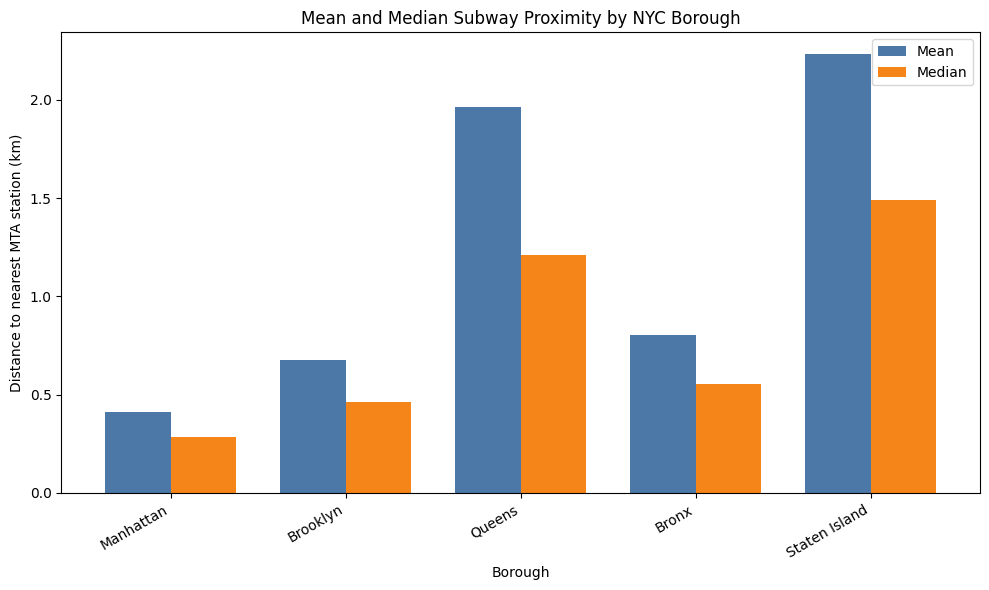

In [24]:
# Compare the mean and median subway-proximity values across the five NYC boroughs.
ax = borough_summary[["mean", "median"]].plot(
    kind="bar",
    figsize=(10, 6),
    color=["#4C78A8", "#F58518"],
    width=0.75,
)
ax.set_title("Mean and Median Subway Proximity by NYC Borough")
ax.set_xlabel("Borough")
ax.set_ylabel("Distance to nearest MTA station (km)")
ax.legend(["Mean", "Median"], title=None)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


**Interpretation:** The chart compares typical subway proximity across the five NYC boroughs. Differences between the mean and median indicate where a smaller number of distant taxi zones raise the borough average.


## 25 Validate the Final Zone-Level Data


In [25]:
# Confirm that every TLC LocationID has one complete and non-negative proximity value.
validation = pd.Series({
    "rows_equal_262": len(zone_proximity) == 262,
    "LocationID_unique": zone_proximity["LocationID"].is_unique,
    "no_missing_values": not zone_proximity.isna().any().any(),
    "non_negative_distances": zone_proximity["subway_proximity_km"].ge(0).all(),
})
display(validation.to_frame("passed"))
assert validation.all(), "The final MTA proximity data failed validation."


,passed
rows_equal_262,True
LocationID_unique,True
no_missing_values,True
non_negative_distances,True


**Interpretation:** All checks must pass to confirm that the final data contains one valid proximity value for every TLC taxi zone.


## 26 Examine the Distribution of Subway-Proximity Values


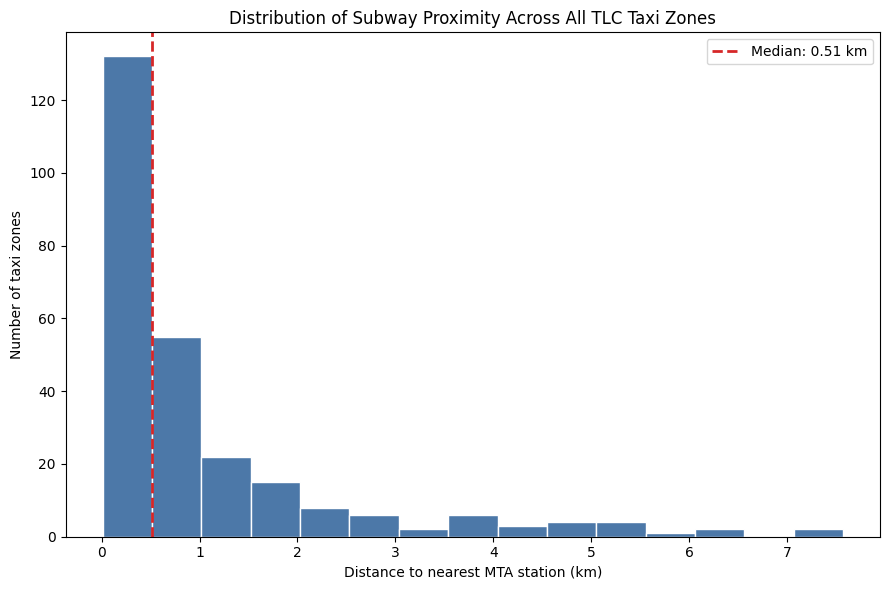

In [26]:
# Show the distribution of the final proximity values across all 263 TLC taxi zones.
proximity_values = zone_proximity["subway_proximity_km"]
median_proximity = proximity_values.median()

fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(proximity_values, bins=15, color="#4C78A8", edgecolor="white")
ax.axvline(
    median_proximity, color="#D62728", linestyle="--", linewidth=2,
    label=f"Median: {median_proximity:.2f} km"
)
ax.set_title("Distribution of Subway Proximity Across All TLC Taxi Zones")
ax.set_xlabel("Distance to nearest MTA station (km)")
ax.set_ylabel("Number of taxi zones")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation:** Most taxi zones are expected to be concentrated at shorter distances, while a smaller number appear farther from an MTA station. This chart checks the overall range and highlights high-distance cases across the complete 263-zone output, including the EWR record retained for integration.


## 27 Save the Processed Proximity Data


In [27]:
# Save the validated 263-zone proximity data as a CSV file for later integration.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
zone_proximity.to_csv(OUTPUT_FILE, index=False)

print("Saved to:", OUTPUT_FILE)
print("Saved rows:", len(zone_proximity))


Saved to: C:\Asia Pacific University\All Module Notes\Semister-5\Investigations\FYP Semester 1\Progress\fyp\processed_outputs\mta_subway\nyc_taxi_zone_subway_proximity.csv
Saved rows: 262


**Interpretation:** The saved-row count confirms that the output file contains the full 263-zone proximity lookup required by the final integration process.
